# FluidX3D Force Validation Lab

Use this notebook to run, label, collect, and plot force-validation experiments for NACA, Ahmed, and skijumper cases.

The C++ executable is still the source of truth for simulations. This notebook only organizes runs and reads CSV output from `bin/export/force_validation/`.

## First-Time Setup

From the repo root in a VS Code terminal:

```powershell
python -m venv .venv
.\.venv\Scripts\Activate.ps1
python -m pip install -r py\requirements.txt
```

If PowerShell blocks `Activate.ps1`, run this once:

```powershell
Set-ExecutionPolicy -Scope CurrentUser -ExecutionPolicy RemoteSigned
```

Then open this notebook and select the `.venv` kernel. You only need to do this once per machine.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "py"))

import force_validation as fv

ROOT, fv.local_executable(ROOT), fv.export_dir(ROOT)

(WindowsPath('c:/dev/fxms'),
 WindowsPath('c:/dev/fxms/bin/FluidX3D.exe'),
 WindowsPath('c:/dev/fxms/bin/export/force_validation'))

## Define a Local Run

Keep `RUN_NOW = False` until the command looks right. Set it to `True` to actually launch the executable.

In [ ]:
RUN_NOW = True

local_spec = fv.RunSpec(
    case="ahmed",      # all, naca, ahmed, skijumper
    memory_mb=1000,
    gpu_ids=("0",),
    label="local-debug-skijumper-512mb",
    location="local-5080-16gb",
    notes="Small local smoke run from notebook",
)

result = fv.run_local(local_spec, ROOT, dry_run=not RUN_NOW)
result

['c:\\dev\\fxms\\bin\\FluidX3D.exe', 'skijumper', '512', '0']

If `RUN_NOW = True`, inspect stdout/stderr here. The helper writes an entry to `py/run_log.csv` after the process exits.

In [3]:
if RUN_NOW:
    print("returncode:", result.returncode)
    print("--- stdout ---")
    print(result.stdout[-4000:])
    print("--- stderr ---")
    print(result.stderr[-4000:])

## Remote Run Scaffold

This is intentionally dry-run for now. Once the Linux server details are known, fill in `host`, `user`, `repo_path`, and `ssh_port`.

Expected server setup later: repo cloned/built on the server, STLs present, and SSH access from this PC.

In [4]:
REMOTE_RUN_NOW = False
REMOTE_COPY_NOW = False

remote = fv.RemoteConfig(
    host="your.server.host",
    user="your_user",
    repo_path="/home/your_user/fxms",
    ssh_port=22,
    executable="bin/FluidX3D",
)

remote_spec = fv.RunSpec(
    case="all",
    memory_mb=40000,
    gpu_ids=("0",),
    label="remote-all-40gb",
    location="linux-server-56gb-vram",
    notes="High-resolution remote run placeholder",
)

remote_cmd = fv.run_remote(remote_spec, remote, dry_run=not REMOTE_RUN_NOW)
copy_cmd = fv.copy_remote_csvs(remote, destination=fv.export_dir(ROOT), dry_run=not REMOTE_COPY_NOW)

remote_cmd, copy_cmd

(['ssh',
  '-p',
  '22',
  'your_user@your.server.host',
  'cd /home/your_user/fxms && bin/FluidX3D all 40000 0'],
 ['scp',
  '-P',
  '22',
  'your_user@your.server.host:/home/your_user/fxms/bin/export/force_validation/*.csv',
  'c:\\dev\\fxms\\bin\\export\\force_validation'])

## Load CSV Output

This reads all CSV files currently in `bin/export/force_validation/`.

In [5]:
df = fv.load_force_csvs(ROOT)
log = fv.load_run_log(ROOT)

print(f"CSV rows: {len(df)}")
print(f"Logged runs: {len(log)}")
df.head()

CSV rows: 30
Logged runs: 0


,case,memory_mb,Nx,Ny,Nz,step,time_s,Fx_N,Fy_drag_N,Fz_lift_N,...,Mz_Nm,Cd,Cl,Cs,Re,tau,nu_lbm,ref_area_m2,ref_length_m,source_file
0,ahmed,2000,278,747,150,1550,0.032494,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2821622.0,0.500013,0.000004,0.112032,1.044,ahmed_2000MB.csv
1,ahmed,2000,278,747,150,1600,0.033542,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2821622.0,0.500013,0.000004,0.112032,1.044,ahmed_2000MB.csv
2,ahmed,2000,278,747,150,1650,0.03459,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2821622.0,0.500013,0.000004,0.112032,1.044,ahmed_2000MB.csv
3,ahmed,2000,278,747,150,1700,0.035639,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2821622.0,0.500013,0.000004,0.112032,1.044,ahmed_2000MB.csv
4,ahmed,2000,278,747,150,1750,0.036687,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2821622.0,0.500013,0.000004,0.112032,1.044,ahmed_2000MB.csv


In [6]:
fv.latest_samples(df)

,case,memory_mb,Nx,Ny,Nz,step,time_s,Fx_N,Fy_drag_N,Fz_lift_N,...,Mz_Nm,Cd,Cl,Cs,Re,tau,nu_lbm,ref_area_m2,ref_length_m,source_file
19,naca,2000,250,500,250,2000,54126.070312,3.34725,-232.844376,221.370834,...,-3981.848145,-0.108544,0.103195,0.00156,4000000.25,0.500005,0.000002,1000665.875,1000.665955,naca_2000MB.csv
9,ahmed,2000,278,747,150,2000,0.041928,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2821622.0,0.500013,0.000004,0.112032,1.044,ahmed_2000MB.csv
29,skijumper,2000,308,411,247,2000,0.077859,3.749338,255.104462,209.261673,...,-1.80985,0.092555,0.075923,0.00136,6756757.0,0.500018,0.000006,7.2,4.0,skijumper_2000MB.csv


In [7]:
fv.summarize_runs(df)

case memory_mb           source_file  Fx_N                      \
                                             count      mean       std   
0      ahmed      2000      ahmed_2000MB.csv    10       0.0  0.000000   
1       naca      2000       naca_2000MB.csv    10  0.189686  5.597383   
2  skijumper      2000  skijumper_2000MB.csv    10 -0.444079  3.141077   

                      Fy_drag_N              ...    Cl                      \
        min       max     count        mean  ... count      mean       std   
0       0.0       0.0        10         0.0  ...    10       0.0  0.000000   
1 -8.227942  5.101981        10  122.864409  ...    10  0.006293  0.064173   
2 -4.756204  3.749338        10  235.685434  ...    10  0.075248  0.003571   

                         Cs                                          
        min       max count      mean       std       min       max  
0       0.0       0.0    10       0.0  0.000000       0.0       0.0  
1 -0.086731  0.103195    10  0.000088  0.002609 -0.003836  0.002378  
2  0.069193   0.08046    10 -0.000161  0.001140 -0.001726   0.00136  

[3 rows x 33 columns]

## Plot Force Convergence

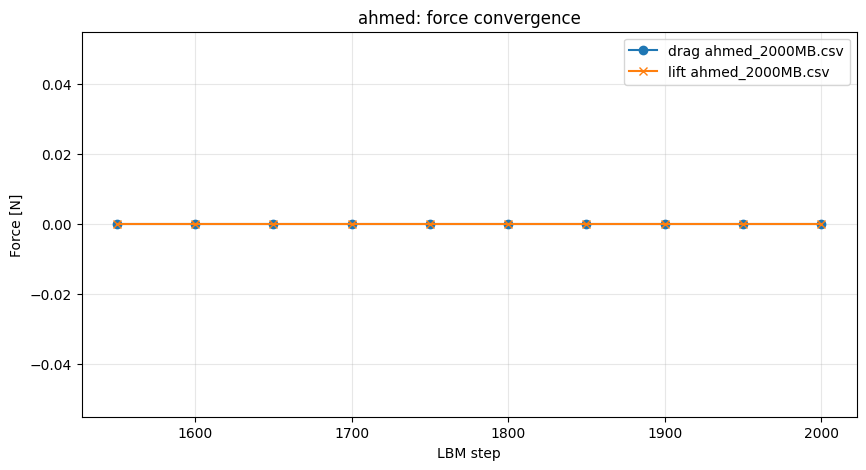

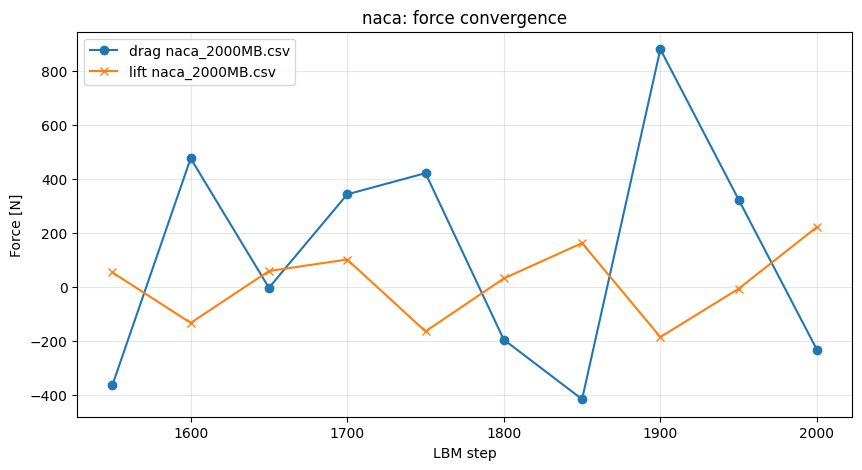

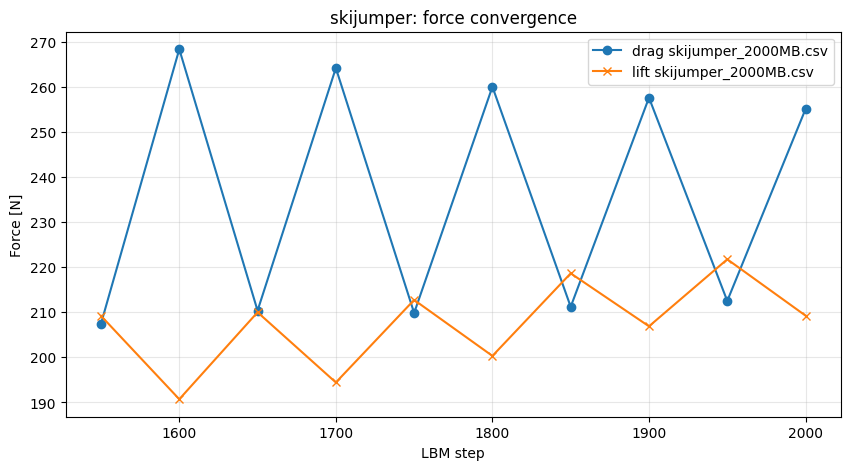

In [8]:
import matplotlib.pyplot as plt

if df.empty:
    print("No CSV data yet. Run an experiment first, then reload this cell.")
else:
    for case, case_df in df.groupby("case"):
        fig, ax = plt.subplots(figsize=(10, 5))
        for source_file, run_df in case_df.groupby("source_file"):
            ax.plot(run_df["step"], run_df["Fy_drag_N"], marker="o", label=f"drag {source_file}")
            ax.plot(run_df["step"], run_df["Fz_lift_N"], marker="x", label=f"lift {source_file}")
        ax.set_title(f"{case}: force convergence")
        ax.set_xlabel("LBM step")
        ax.set_ylabel("Force [N]")
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.show()

## Plot Coefficients

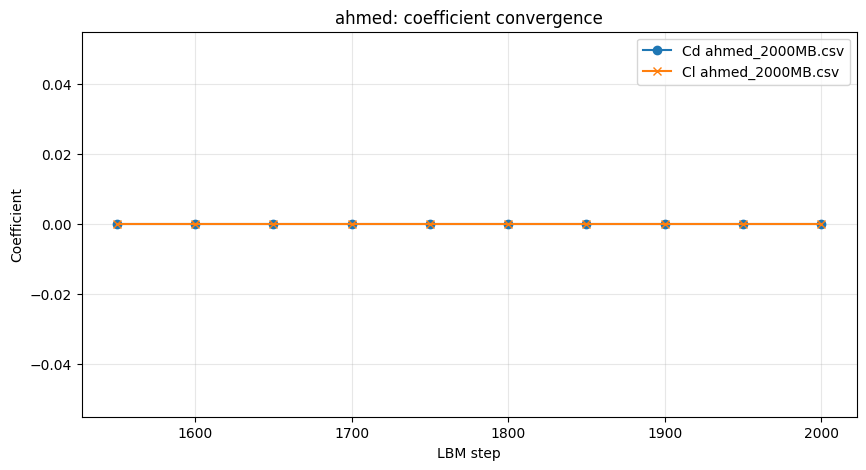

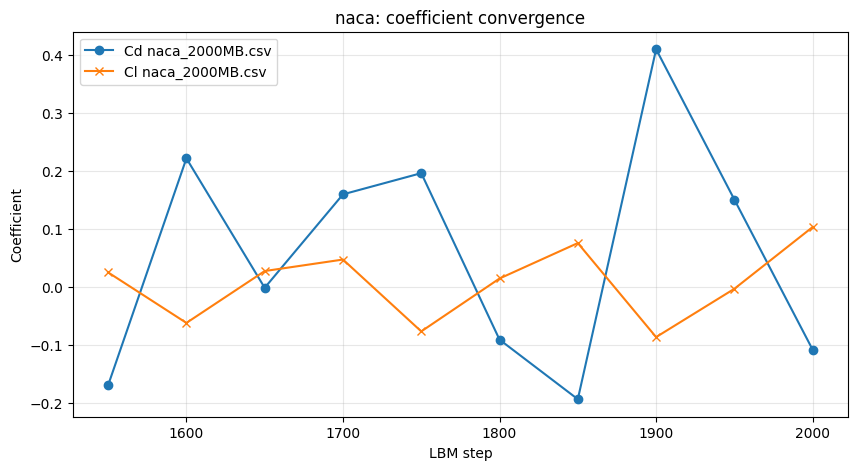

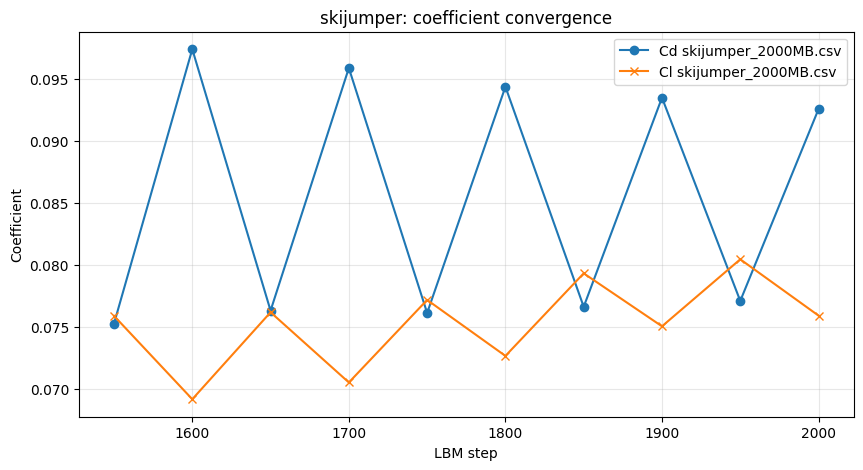

In [9]:
if df.empty:
    print("No CSV data yet. Run an experiment first, then reload this cell.")
else:
    for case, case_df in df.groupby("case"):
        fig, ax = plt.subplots(figsize=(10, 5))
        for source_file, run_df in case_df.groupby("source_file"):
            ax.plot(run_df["step"], run_df["Cd"], marker="o", label=f"Cd {source_file}")
            ax.plot(run_df["step"], run_df["Cl"], marker="x", label=f"Cl {source_file}")
        ax.set_title(f"{case}: coefficient convergence")
        ax.set_xlabel("LBM step")
        ax.set_ylabel("Coefficient")
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.show()

## Notes for Interpreting Runs

- For skijumper, raw `Fy_drag_N` and `Fz_lift_N` are the primary quantities.
- Skijumper coefficients use dummy-bound box area, so treat them as run-to-run comparators rather than final wind-tunnel coefficients.
- For memory sweeps, compare the last row of each CSV first, then inspect convergence plots.